In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [3]:
# Load dataset

df = pd.read_csv("D:\Customer-Segmentation-and-churn-Prediction\data\Bank Customer Churn Prediction.csv")


<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
C:\Users\atchu\AppData\Local\Temp\ipykernel_5612\247456009.py:3: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Customer-Segmentation-and-churn-Prediction\data\Bank Customer Churn Prediction.csv")


In [4]:
df.shape

(10000, 12)

In [5]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [6]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
# Check missing values
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [15]:
churn_percentage = (df["churn"].value_counts(normalize=True) * 100)
print(churn_percentage)

churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [16]:
plt.style.use('ggplot')

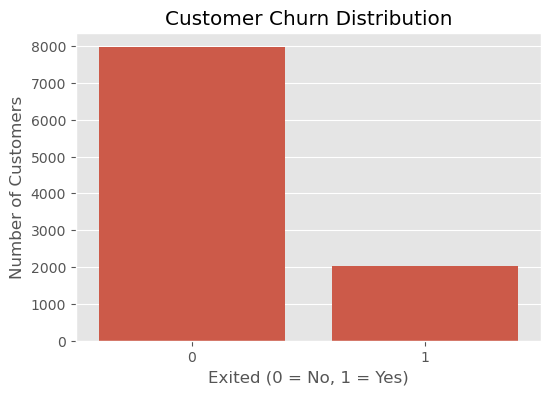

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

plt.show()

<Figure size 600x400 with 0 Axes>

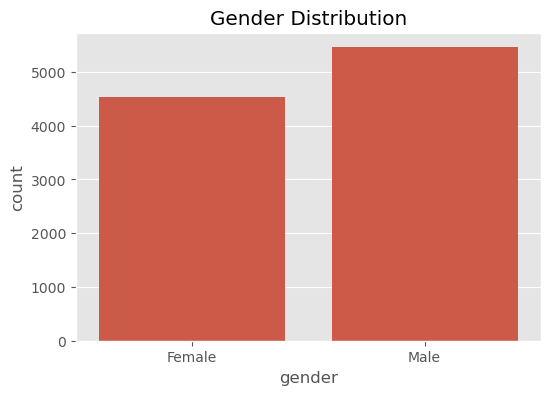

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

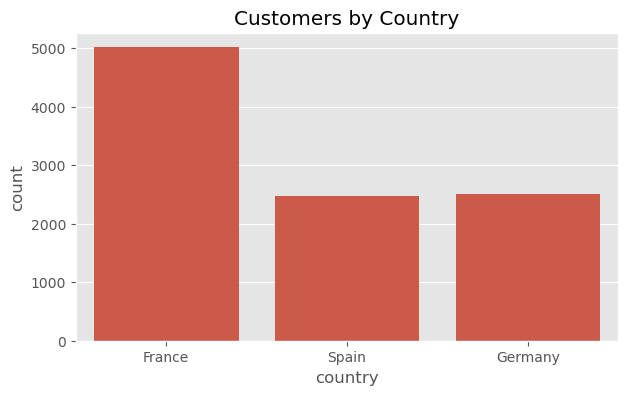

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(x='country', data=df)
plt.title('Customers by Country')
plt.savefig('../images/geography_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

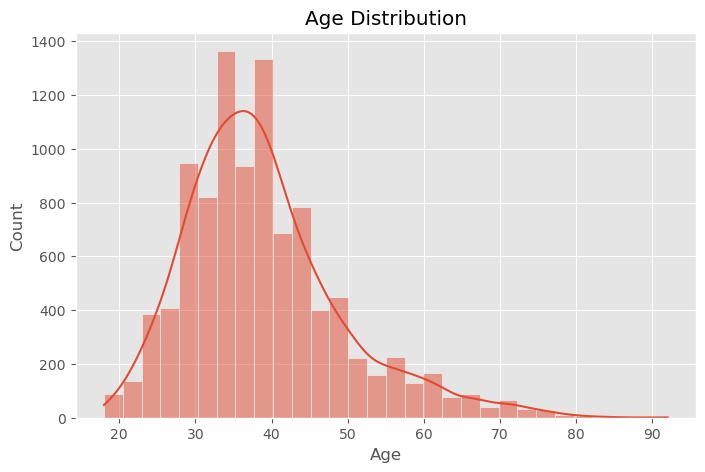

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.savefig('../images/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

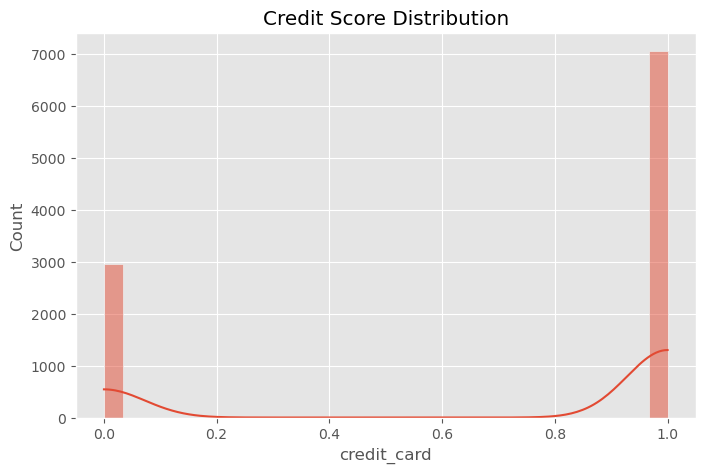

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['credit_card'], bins=30, kde=True)
plt.title('Credit Score Distribution')
plt.savefig('../images/credit_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

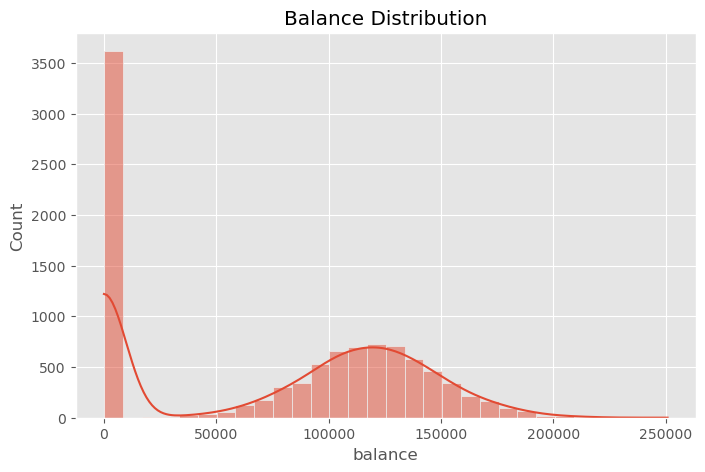

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['balance'], bins=30, kde=True)
plt.title('Balance Distribution')
plt.savefig('../images/balance_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

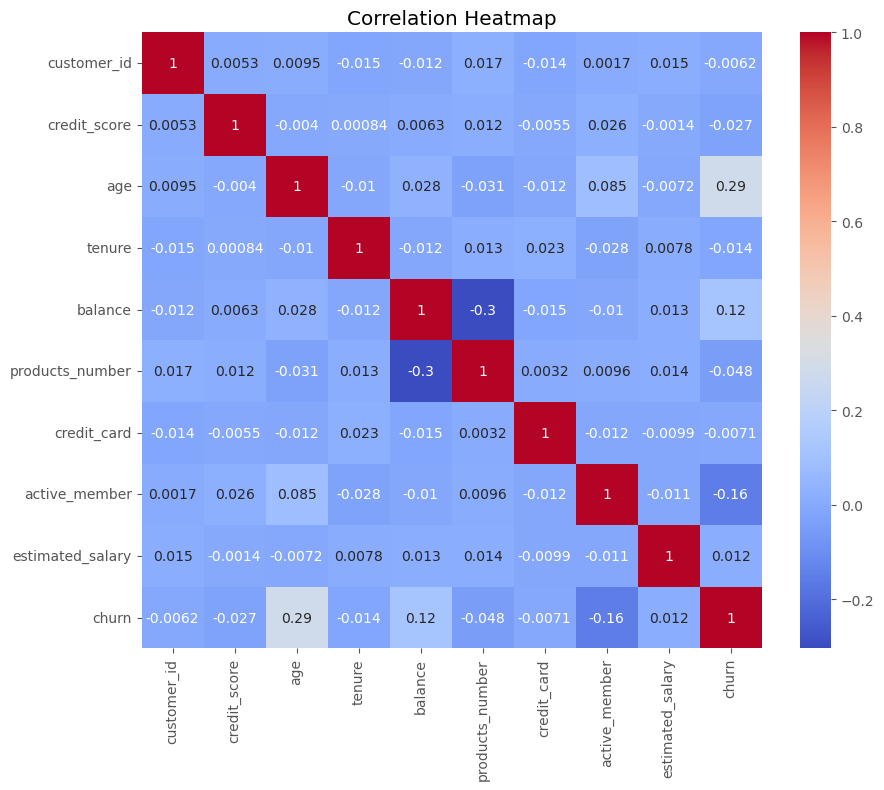

In [34]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

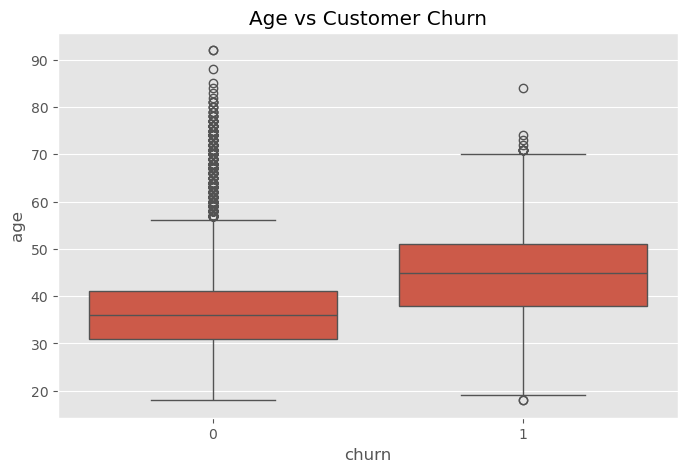

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='age', data=df)
plt.title('Age vs Customer Churn')
plt.savefig('../images/age_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

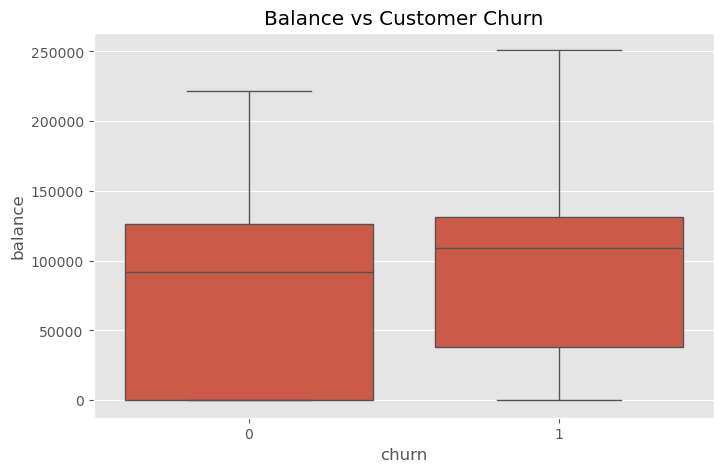

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Balance vs Customer Churn')
plt.savefig('../images/balance_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [38]:
features = ['credit_score', 'age', 'balance', 'estimated_salary']
X = df[features]
X.head()

,credit_score,age,balance,estimated_salary
0,619,42,0.00,101348.88
1,608,41,83807.86,112542.58
2,502,42,159660.80,113931.57
3,699,39,0.00,93826.63
4,850,43,125510.82,79084.10


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\atchu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\atchu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\atchu\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\atchu\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\atchu\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

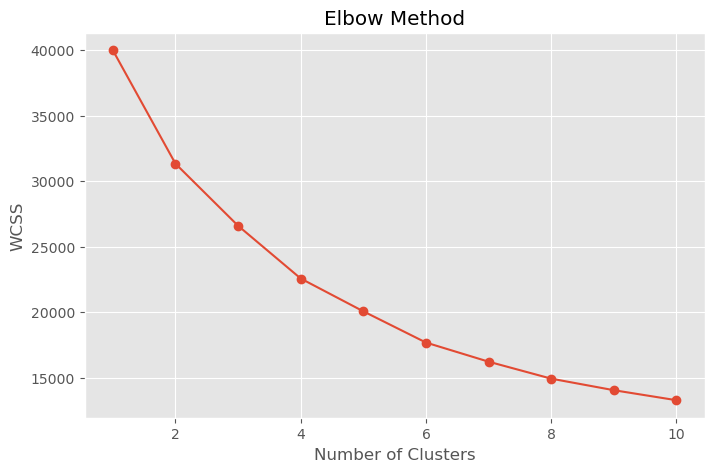

In [41]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.savefig("../images/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
k = 4
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Cluster
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,2
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0


In [43]:
df['Cluster'].value_counts()


Cluster
2    3325
3    2732
0    2676
1    1267
Name: count, dtype: int64

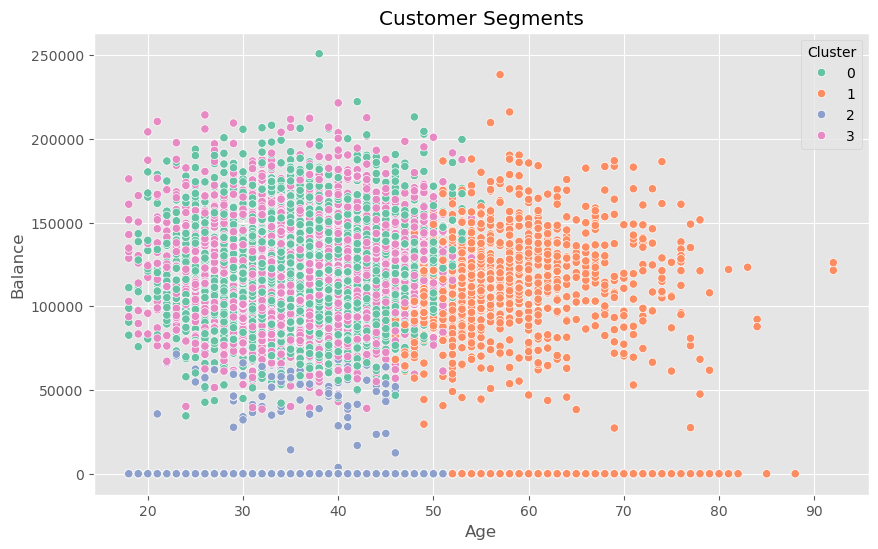

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='age',
    y='balance',
    hue='Cluster',
    data=df,
    palette='Set2'
)

plt.title("Customer Segments")
plt.xlabel("Age")
plt.ylabel("Balance")

plt.savefig("../images/customer_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
cluster_summary = df.groupby('Cluster')[['credit_score','age','balance','estimated_salary']].mean()
cluster_summary

,credit_score,age,balance,estimated_salary
Cluster,,,,
0,655.072870,36.121824,122008.383655,49707.232672
1,649.018942,59.292818,80640.615533,96722.190118
2,648.401203,35.742256,1390.845759,99385.665669
3,649.367496,36.086750,121364.654535,151859.989367


In [49]:
cluster_names = {
    0: "Mid-Balance Customers",
    1: "Senior Customers",
    2: "Low-Balance Customers",
    3: "High-Value Customers"
}
df["Customer Segment"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Customer Segment"]].head()

,Cluster,Customer Segment
0,2,Low-Balance Customers
1,3,High-Value Customers
2,3,High-Value Customers
3,2,Low-Balance Customers
4,0,Mid-Balance Customers


In [50]:
df.to_csv("../data/customer_segmented.csv", index=False)

In [51]:
import joblib

joblib.dump(kmeans, "../models/kmeans_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
     ConfusionMatrixDisplay
)
df_model = df.copy()

df_model = df_model.drop(
    columns=[
        "CustomerId",
        "Surname"
    ],
    errors="ignore"
)

In [ ]:
encoder = LabelEncoder()

df_model["gender"] = encoder.fit_transform(df_model["gender"])
df_model["country"] = encoder.fit_transform(df_model[
    "country"])
df_model["Customer Segment"] = encoder.fit_transform(df_model["Customer Segment"])


In [58]:
X = df_model.drop("churn", axis=1)
y = df_model["churn"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 0.789
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1607
           1       0.32      0.07      0.11       393

    accuracy                           0.79      2000
   macro avg       0.56      0.52      0.50      2000
weighted avg       0.71      0.79      0.73      2000



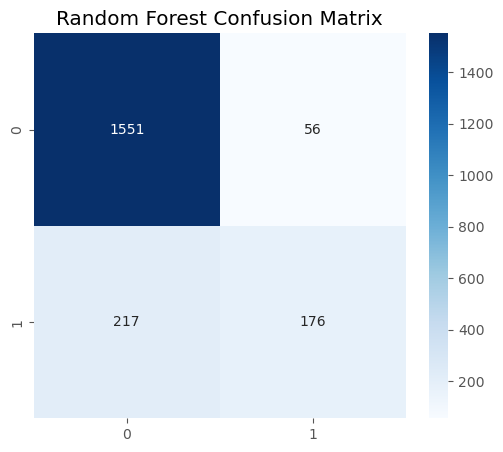

In [60]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.savefig("../images/confusion_matrix.png", dpi=300)

plt.show()

In [80]:
print("Random Forest Accuracy")
print("-----------------------")
print("Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy
-----------------------
Accuracy: 0.8635


In [83]:
import joblib

joblib.dump(rf, "../models/churn_prediction_model.pkl")

['../models/churn_prediction_model.pkl']

In [70]:
df_model = df.copy()
columns_to_drop = ["CustomerId", "Surname"]

df_model.drop(columns=columns_to_drop, inplace=True, errors="ignore")

In [74]:
le_gender = LabelEncoder()
le_geo = LabelEncoder()
le_segment = LabelEncoder()
df_model["gender"] = le_gender.fit_transform(df_model["gender"])
df_model["country"] = le_geo.fit_transform(df_model["country"])
df_model["Customer Segment"] = le_segment.fit_transform(df_model["Customer Segment"])

In [75]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,age,0.188355
7,products_number,0.126643
0,customer_id,0.116217
10,estimated_salary,0.114557
1,credit_score,0.113277
6,balance,0.106260
5,tenure,0.068189
9,active_member,0.048940
2,country,0.033337
12,Customer Segment,0.031958


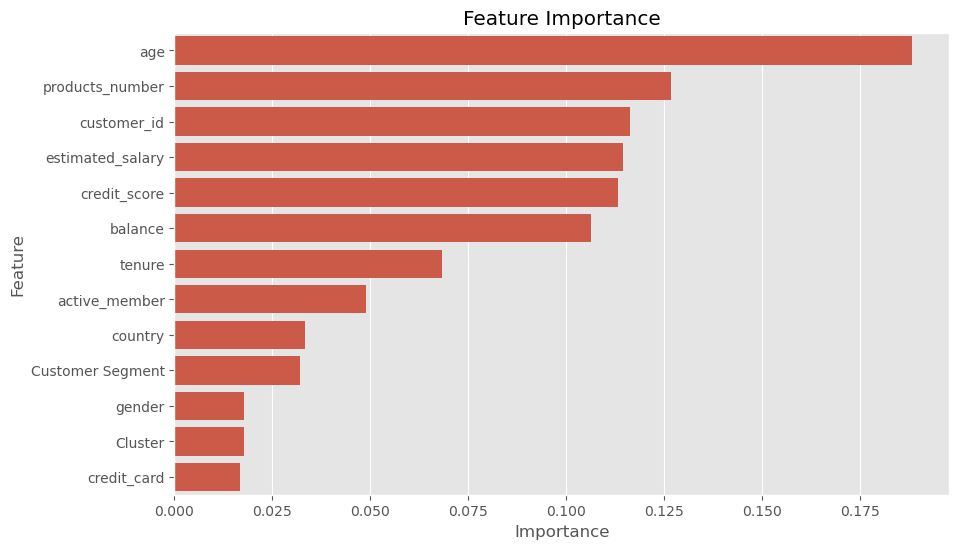

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [77]:
joblib.dump(rf, "../models/churn_prediction_model.pkl")

['../models/churn_prediction_model.pkl']

In [78]:
joblib.dump(le_gender, "../models/gender_encoder.pkl")
joblib.dump(le_geo, "../models/geography_encoder.pkl")
joblib.dump(le_segment, "../models/segment_encoder.pkl")

['../models/segment_encoder.pkl']

In [79]:
df_model.to_csv("../data/final_customer_dataset.csv", index=False)

In [82]:
import joblib

joblib.dump(rf, "../models/churn_prediction_model.pkl")

['../models/churn_prediction_model.pkl']